STEP 3 – DATA EXPLORATION

[1] First 5 rows:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa

[2] Dataset shape (rows, columns): (150, 5)

[3] Column names and data types:
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

[4] Statistical summary:
       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count     150.000000    150.000000     150.000000    150.000000
mean        5.843333      3.054000       3.758667      1.198667
std         0.828066      0.433594       1.764420      0.763161
min         4.300

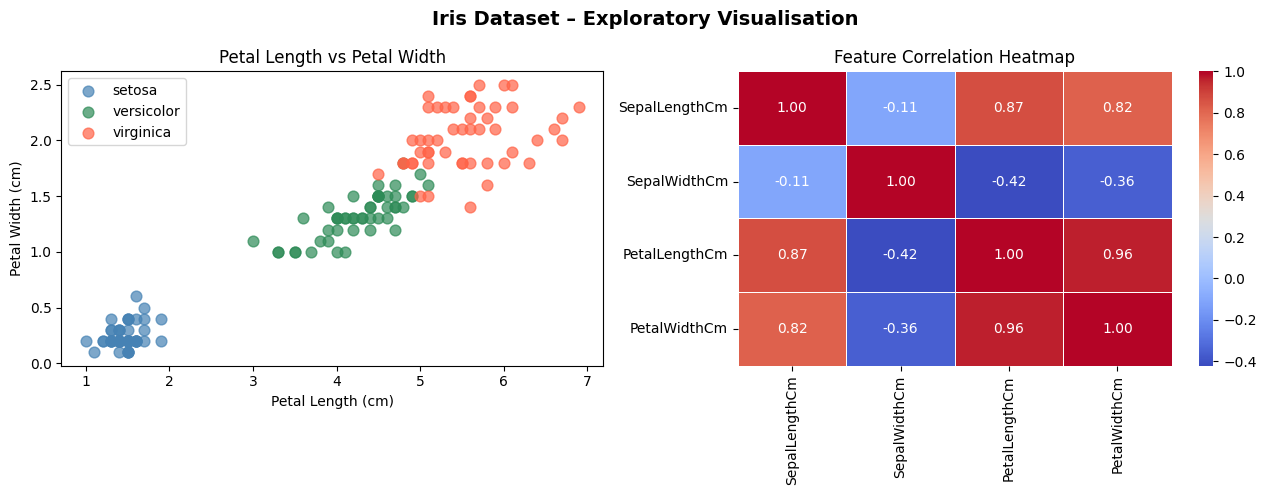

[Saved: eda_plots.png]

STEP 5 – DATA PREPARATION

Label encoding: {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}

Training samples : 120
Test samples     : 30

STEP 6 – MODEL TRAINING & EVALUATION
  Logistic Regression       Accuracy: 93.33%
  Decision Tree             Accuracy: 90.00%
  Random Forest             Accuracy: 90.00%
  SVM (RBF)                 Accuracy: 96.67%

BEST MODEL: SVM (RBF)  (96.67% accuracy)

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



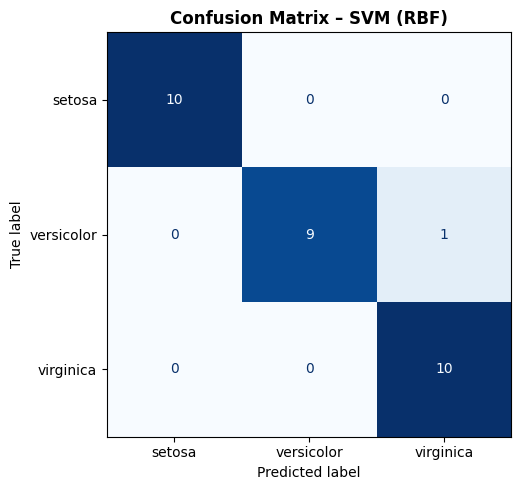

[Saved: confusion_matrix.png]


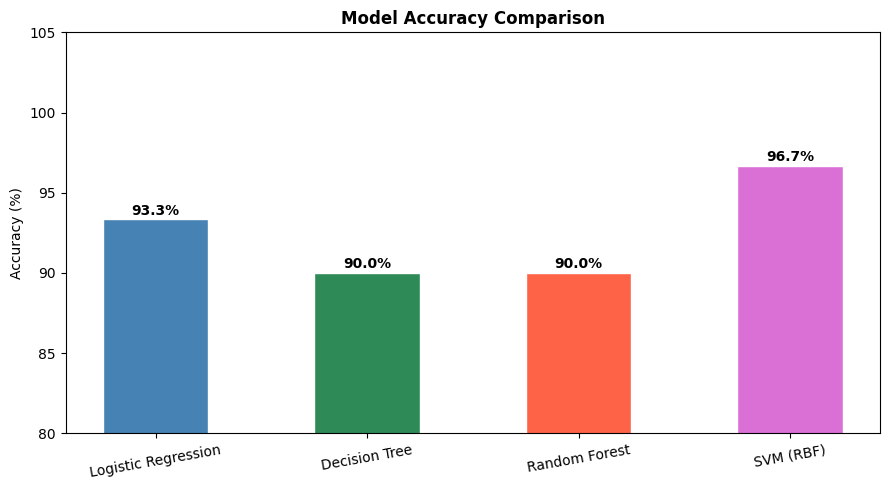

[Saved: model_comparison.png]


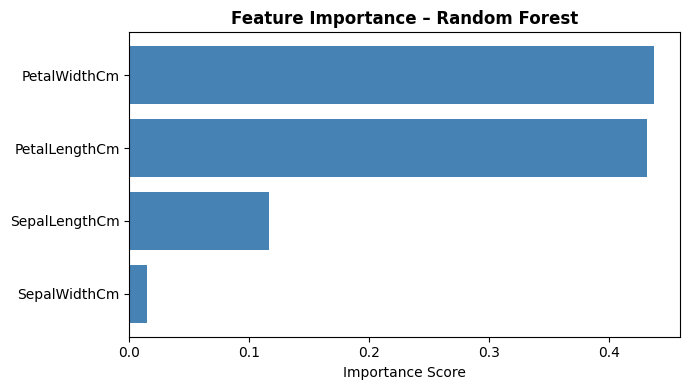

[Saved: feature_importance.png]

STEP 11 – PREDICTING A NEW FLOWER SAMPLE

Input measurements : [5.1, 3.5, 1.4, 0.2]
Predicted species  : Iris-setosa

✅ Done! All outputs saved as PNG files.


In [3]:
# ============================================================
#   Iris Flower Species Classification
#   Task: Train a model to classify Iris species using
#         sepal/petal measurements
#   Libraries: pandas, scikit-learn, matplotlib, seaborn
# ============================================================

# ── Step 1: Import Libraries ─────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import warnings
warnings.filterwarnings("ignore")


# ── Step 2: Load Dataset ──────────────────────────────────────
# You can load from a local CSV or directly from scikit-learn
# Option A – Load from the uploaded CSV file:
df = pd.read_csv("Iris.csv")          # make sure Iris.csv is in the same folder
df.drop(columns=["Id"], inplace=True) # remove the Id column – not needed

# Option B – Load directly from scikit-learn (no CSV needed):
# from sklearn.datasets import load_iris
# data = load_iris(as_frame=True)
# df = data.frame
# df.rename(columns={
#     "sepal length (cm)": "SepalLengthCm",
#     "sepal width (cm)":  "SepalWidthCm",
#     "petal length (cm)": "PetalLengthCm",
#     "petal width (cm)":  "PetalWidthCm",
#     "target":            "Species"
# }, inplace=True)
# df["Species"] = df["Species"].map({0:"Iris-setosa",
#                                     1:"Iris-versicolor",
#                                     2:"Iris-virginica"})


# ── Step 3: Explore the Data ──────────────────────────────────
print("=" * 55)
print("STEP 3 – DATA EXPLORATION")
print("=" * 55)

print("\n[1] First 5 rows:")
print(df.head())

print("\n[2] Dataset shape (rows, columns):", df.shape)

print("\n[3] Column names and data types:")
print(df.dtypes)

print("\n[4] Statistical summary:")
print(df.describe())

print("\n[5] Missing values:")
print(df.isnull().sum())

print("\n[6] Species count:")
print(df["Species"].value_counts())


# ── Step 4: Visualise the Data ────────────────────────────────
print("\n[Plotting exploratory charts...]")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Iris Dataset – Exploratory Visualisation", fontsize=14, fontweight="bold")

# Scatter: petal dimensions
for species, color in zip(
    ["Iris-setosa", "Iris-versicolor", "Iris-virginica"],
    ["steelblue", "seagreen", "tomato"],
):
    subset = df[df["Species"] == species]
    axes[0].scatter(
        subset["PetalLengthCm"],
        subset["PetalWidthCm"],
        label=species.replace("Iris-", ""),
        color=color,
        alpha=0.7,
        s=60,
    )
axes[0].set_xlabel("Petal Length (cm)")
axes[0].set_ylabel("Petal Width (cm)")
axes[0].set_title("Petal Length vs Petal Width")
axes[0].legend()

# Correlation heatmap
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    ax=axes[1],
    linewidths=0.5,
)
axes[1].set_title("Feature Correlation Heatmap")

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=120)
plt.show()
print("[Saved: eda_plots.png]")


# ── Step 5: Prepare Data for ML ──────────────────────────────
print("\n" + "=" * 55)
print("STEP 5 – DATA PREPARATION")
print("=" * 55)

# Separate features (X) and label (y)
X = df.drop("Species", axis=1)             # 4 feature columns
y = df["Species"]                           # target column

# Encode species labels → numbers  (setosa=0, versicolor=1, virginica=2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("\nLabel encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

# Split into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"\nTraining samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

# Scale features (mean = 0, std = 1) – important for SVM & Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


# ── Step 6: Train Multiple Models ────────────────────────────
print("\n" + "=" * 55)
print("STEP 6 – MODEL TRAINING & EVALUATION")
print("=" * 55)

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree"      : DecisionTreeClassifier(random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)"          : SVC(kernel="rbf", random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    acc   = accuracy_score(y_test, preds)
    results[name] = {"model": model, "preds": preds, "accuracy": acc}
    print(f"  {name:<25} Accuracy: {acc * 100:.2f}%")


# ── Step 7: Best Model – Detailed Report ─────────────────────
best_name  = max(results, key=lambda n: results[n]["accuracy"])
best_preds = results[best_name]["preds"]

print(f"\n{'='*55}")
print(f"BEST MODEL: {best_name}  ({results[best_name]['accuracy']*100:.2f}% accuracy)")
print(f"{'='*55}")

print("\nClassification Report:")
print(
    classification_report(
        y_test, best_preds, target_names=le.classes_
    )
)


# ── Step 8: Confusion Matrix ─────────────────────────────────
cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[c.replace("Iris-", "") for c in le.classes_],
)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix – {best_name}", fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120)
plt.show()
print("[Saved: confusion_matrix.png]")


# ── Step 9: Model Accuracy Comparison Bar Chart ──────────────
names = list(results.keys())
accs  = [results[n]["accuracy"] * 100 for n in names]

plt.figure(figsize=(9, 5))
bars = plt.bar(
    names, accs,
    color=["steelblue", "seagreen", "tomato", "orchid"],
    edgecolor="white", width=0.5,
)
for bar, acc in zip(bars, accs):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{acc:.1f}%",
        ha="center", fontweight="bold",
    )
plt.ylim(80, 105)
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison", fontweight="bold")
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120)
plt.show()
print("[Saved: model_comparison.png]")


# ── Step 10: Feature Importance (Random Forest) ──────────────
rf_model  = results["Random Forest"]["model"]
feat_imp  = rf_model.feature_importances_
feat_names = X.columns.tolist()

sorted_idx = np.argsort(feat_imp)
plt.figure(figsize=(7, 4))
plt.barh(
    [feat_names[i] for i in sorted_idx],
    feat_imp[sorted_idx],
    color="steelblue",
)
plt.xlabel("Importance Score")
plt.title("Feature Importance – Random Forest", fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120)
plt.show()
print("[Saved: feature_importance.png]")


# ── Step 11: Predict a New Sample ────────────────────────────
print("\n" + "=" * 55)
print("STEP 11 – PREDICTING A NEW FLOWER SAMPLE")
print("=" * 55)

# Sample: [SepalLength, SepalWidth, PetalLength, PetalWidth]
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])   # expected: Iris-setosa
new_sample_sc = scaler.transform(new_sample)

best_model = results[best_name]["model"]
prediction = best_model.predict(new_sample_sc)
species    = le.inverse_transform(prediction)[0]

print(f"\nInput measurements : {new_sample[0].tolist()}")
print(f"Predicted species  : {species}")

print("\n✅ Done! All outputs saved as PNG files.")